# 第二周第 3 课

先阅读 [课程讲解](../../docs/week02/03_self_attention.md)。运行前先预测形状与变化，然后从上到下运行。


In [1]:
from pathlib import Path
import sys

# 支持从项目根目录或 Notebook 所在目录启动。
root = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "exercises/week02/attention_utils.py").exists())
sys.path.insert(0, str(root / "exercises/week02"))
import numpy as np
np.set_printoptions(precision=4, suppress=True)


In [2]:
import runpy
experiment = runpy.run_path(str(root / "exercises/week02/03_self_attention.py"))
globals().update({k: v for k, v in experiment.items() if not k.startswith("__")})


X shape=(3, 4)
[[1. 0. 0. 1.]
 [0. 1. 0. 1.]
 [0. 0. 1. 1.]]

Q shape=(3, 2)
[[1. 0.]
 [0. 1.]
 [1. 1.]]

K shape=(3, 2)
[[ 1.  0.]
 [ 0.  1.]
 [ 1. -1.]]

V shape=(3, 3)
[[2. 1. 1.]
 [1. 2. 1.]
 [1. 1. 2.]]

raw shape=(3, 3)
[[ 1.  0.  1.]
 [ 0.  1. -1.]
 [ 1.  1.  0.]]

scores shape=(3, 3)
[[ 0.7071  0.      0.7071]
 [ 0.      0.7071 -0.7071]
 [ 0.7071  0.7071  0.    ]]

A shape=(3, 3)
[[0.4011 0.1978 0.4011]
 [0.284  0.576  0.14  ]
 [0.4011 0.4011 0.1978]]

O shape=(3, 3)
[[1.4011 1.1978 1.4011]
 [1.284  1.576  1.14  ]
 [1.4011 1.4011 1.1978]]

每行权重之和: [1. 1. 1.]
第一行加权求和核对通过: [1.4011 1.1978 1.4011]


## 逐步重算
先看原始点积，再缩放，再按行归一化，最后混合 V。对照上面的结果。


In [3]:
Q, K, V = result["Q"], result["K"], result["V"]
raw = Q @ K.T
print(raw.shape, "\n", raw)


(3, 3) 
 [[ 1.  0.  1.]
 [ 0.  1. -1.]
 [ 1.  1.  0.]]


In [4]:
scores = raw / np.sqrt(Q.shape[1])
print(scores)


[[ 0.7071  0.      0.7071]
 [ 0.      0.7071 -0.7071]
 [ 0.7071  0.7071  0.    ]]


In [5]:
from attention_utils import softmax_rows
A = softmax_rows(scores)
print(A)
print("行和:", A.sum(axis=1))


[[0.4011 0.1978 0.4011]
 [0.284  0.576  0.14  ]
 [0.4011 0.4011 0.1978]]
行和: [1. 1. 1.]


In [6]:
O = A @ V
print(O.shape, "\n", O)
np.testing.assert_allclose(O, result["O"])


(3, 3) 
 [[1.4011 1.1978 1.4011]
 [1.284  1.576  1.14  ]
 [1.4011 1.4011 1.1978]]


Matplotlib is building the font cache; this may take a moment.


['0: 我', '1: 喜欢', '2: 学习']


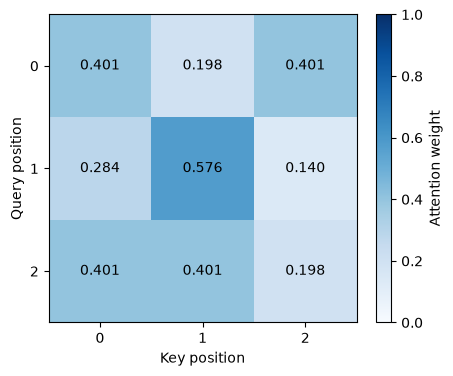

In [7]:
import matplotlib.pyplot as plt
labels = ["0: 我", "1: 喜欢", "2: 学习"]
# 数字位置避免本地字体缺少中文；对应 token 见 labels。
print(labels)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(A, vmin=0, vmax=1, cmap="Blues")
ax.set(xticks=range(3), yticks=range(3), xlabel="Key position", ylabel="Query position")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{A[i, j]:.3f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Attention weight")
plt.show()


## 学习记录

- 我运行前的预测：
- 我修改了什么：
- 实际观察：
- 我能解释的原因与剩余疑问：

完成后记录到 `progress/week02.md`。
